In [664]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

In [665]:
data=pd.read_csv(r"C:\Users\user\OneDrive\Desktop\Titanic\Titanic-Dataset.csv")
df=pd.DataFrame(data)

In [666]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [667]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [668]:
x=df["Age"]
y=df["Survived"]
z=df["Pclass"]
c=df["Sex"]

Text(0, 0.5, 'Survived')

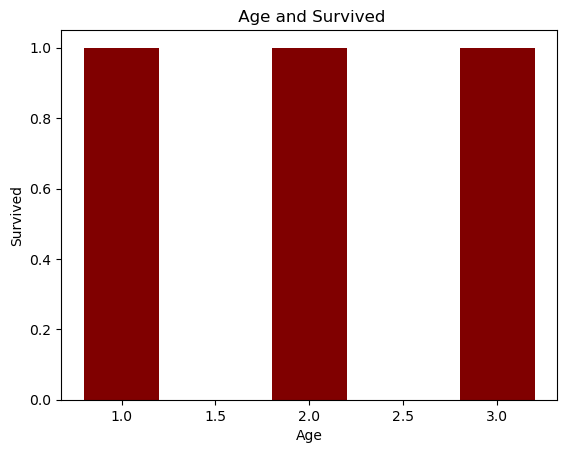

In [669]:
plt.bar(z,y,color="maroon",width=0.4)
plt.title(" Age and Survived")
plt.xlabel("Age")
plt.ylabel("Survived")

In [670]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [671]:
df['Survived'].sum()

342

In [672]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [673]:
df["Pclass"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Pclass
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [674]:
df.groupby("Pclass")["Survived"].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [675]:
df.groupby(df["Age"]<=30)["Survived"].sum()

Age
False    176
True     166
Name: Survived, dtype: int64

In [676]:
value=df["Age"].mean()
print(value)

29.69911764705882


In [677]:
df["Age"].fillna(value,inplace=True)

In [678]:
df["Age"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [679]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [680]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [681]:
df.drop(columns="Cabin",inplace=True)

In [682]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [683]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [684]:
df["Embarked"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Embarked
Non-Null Count  Dtype 
--------------  ----- 
889 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [685]:
df.duplicated().sum()

0

In [686]:
df.drop_duplicates(inplace=True)

In [687]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


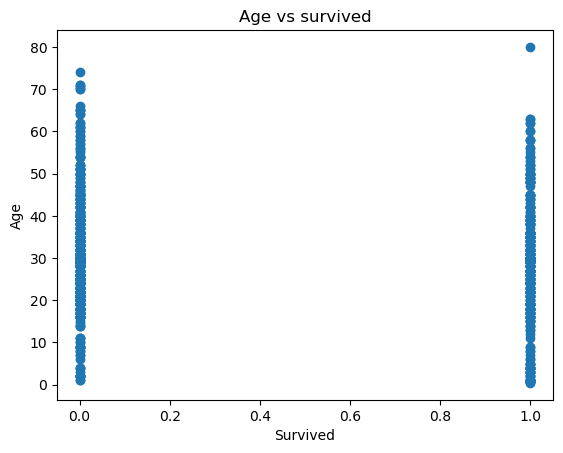

In [688]:
x=df["Survived"]
y=df["Age"]
plt.scatter(x,y)
plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Age vs survived")
plt.show()

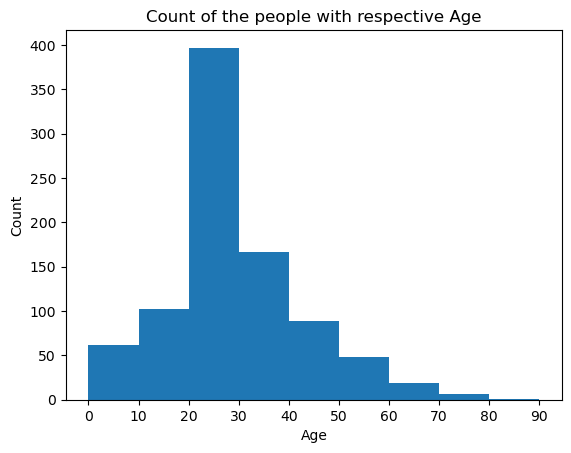

In [689]:

x=df["Age"]
y=[0,10,20,30,40,50,60,70,80,90]
plt.hist(x,y)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Count of the people with respective Age")
plt.xticks([0,10,20,30,40,50,60,70,80,90])
plt.show()

In [690]:
b=df.groupby("Survived")["Age"].sum()

In [691]:
print(b)

Survived
0    16697.889706
1     9764.024118
Name: Age, dtype: float64


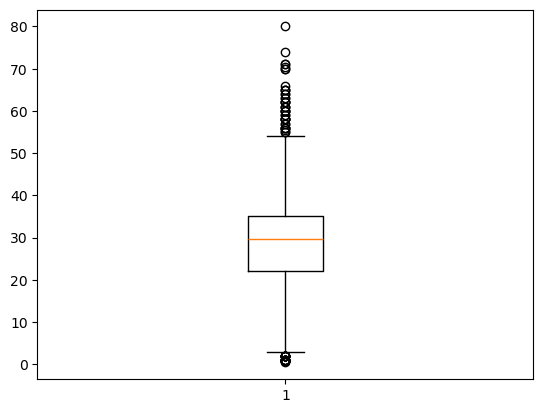

In [692]:

plt.boxplot(df["Age"])
plt.show()


In [693]:
df["Age"].mean()

29.69911764705882

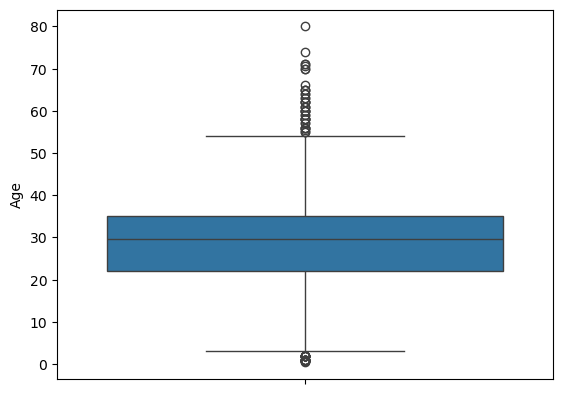

In [694]:
sns.boxplot(df["Age"])
plt.show()

<Axes: >

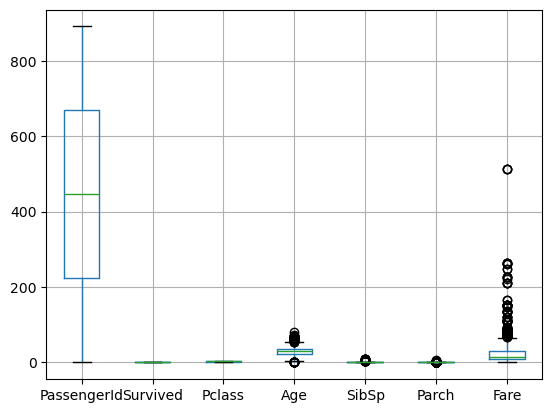

In [695]:
df.boxplot()

In [696]:
df["Age"].min()

0.42

In [697]:
df["Age"].max()

80.0

In [698]:
df["Age"].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [699]:
q3 = np.percentile(df["Age"], 75)

In [700]:
print(q3)

35.0


In [701]:
q1 = np.percentile(df["Age"], 25)

In [702]:
print(q1)
iqr=q3-q1
print(iqr)

22.0
13.0


In [703]:
df.shape

(891, 11)

In [704]:
dnew=df[df["Age"]<(q3+(1.5*iqr))]

In [705]:

dnew1=dnew[dnew["Age"]>(q1-(1.5*iqr))]

In [706]:
dnew1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [707]:
dnew1.shape

(825, 11)

<Axes: ylabel='Age'>

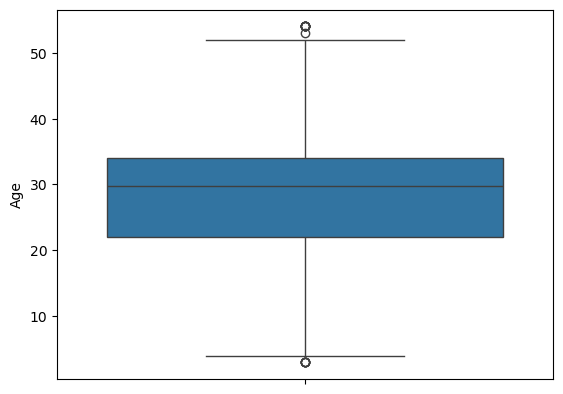

In [708]:
sns.boxplot(dnew1["Age"])

In [709]:
dnew1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 825 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  825 non-null    int64  
 1   Survived     825 non-null    int64  
 2   Pclass       825 non-null    int64  
 3   Name         825 non-null    object 
 4   Sex          825 non-null    object 
 5   Age          825 non-null    float64
 6   SibSp        825 non-null    int64  
 7   Parch        825 non-null    int64  
 8   Ticket       825 non-null    object 
 9   Fare         825 non-null    float64
 10  Embarked     824 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 77.3+ KB


In [811]:

y = dnew1["Survived"]


x = dnew1.drop(columns=[ "Survived","PassengerId", "Name", "Ticket"])


In [813]:
y


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 825, dtype: int64

In [815]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [817]:
x['Embarked'] = x['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})


C:\Users\user\AppData\Local\Temp\ipykernel_12696\3099413516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['Embarked'] = x['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})


In [819]:
x.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,0.0
1,1,female,38.0,1,0,71.2833,1.0
2,3,female,26.0,0,0,7.9250,0.0
3,1,female,35.0,1,0,53.1000,0.0
4,3,male,35.0,0,0,8.0500,0.0


In [821]:
x['Embarked'] = x['Embarked'].fillna(1)



In [823]:
x["Embarked"].info()


<class 'pandas.core.series.Series'>
Index: 825 entries, 0 to 890
Series name: Embarked
Non-Null Count  Dtype  
--------------  -----  
825 non-null    float64
dtypes: float64(1)
memory usage: 12.9 KB


In [825]:
x['Sex'] = x['Sex'].replace({'male': 0, 'female': 1})


C:\Users\user\AppData\Local\Temp\ipykernel_12696\2656771556.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['Sex'] = x['Sex'].replace({'male': 0, 'female': 1})


In [827]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0.0
1,1,1,38.0,1,0,71.2833,1.0
2,3,1,26.0,0,0,7.9250,0.0
3,1,1,35.0,1,0,53.1000,0.0
4,3,0,35.0,0,0,8.0500,0.0


In [829]:
corr=x.corr()

In [831]:
corr

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Pclass,1.000000,-0.158243,-0.286128,0.057760,0.018742,-0.552684,0.043306
Sex,-0.158243,1.000000,-0.058712,0.122328,0.262800,0.187901,0.132522
Age,-0.286128,-0.058712,1.000000,-0.182124,-0.131052,0.091278,-0.007635
SibSp,0.057760,0.122328,-0.182124,1.000000,0.408487,0.166625,-0.060679
Parch,0.018742,0.262800,-0.131052,0.408487,1.000000,0.190001,-0.080635
Fare,-0.552684,0.187901,0.091278,0.166625,0.190001,1.000000,0.069554
Embarked,0.043306,0.132522,-0.007635,-0.060679,-0.080635,0.069554,1.000000


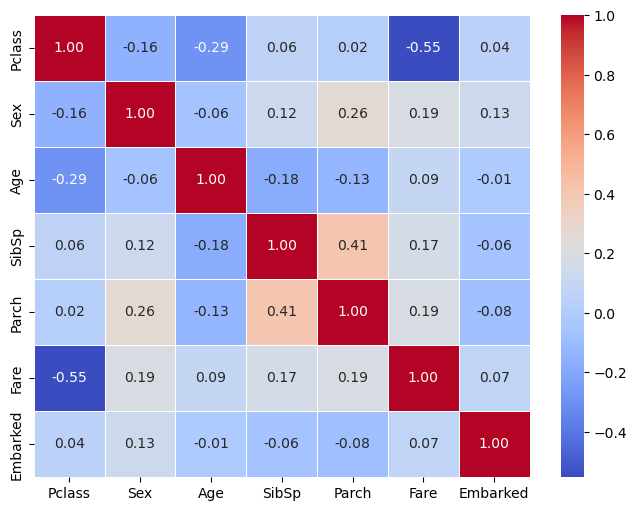

In [874]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)


plt.show()

In [876]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [906]:
model1=LogisticRegression()
model1.fit(x,y)

C:\Users\user\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [908]:
y1predict=model1.predict(x_test)

In [910]:
model1.score(x_train,y_train)*100

80.60606060606061

In [912]:
model1.score(x_test,y_test)*100

82.42424242424242

In [914]:
a = accuracy_score(y_test, y1predict)

In [916]:
print(a)

0.8242424242424242


In [918]:
m3=RandomForestClassifier()
m3.fit(x,y)

RandomForestClassifier()

In [919]:
y3=m3.predict(x_test)

In [920]:
a3=accuracy_score(y_test,y3)

In [924]:
print(a3)

0.9878787878787879
